In [1]:
!pip -q install opencv-python numpy pandas matplotlib tqdm

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ROI_OUT_DIR = "/content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF"
CROPS_DIR = os.path.join(ROI_OUT_DIR, "crops")

print("CROPS_DIR exists?", os.path.exists(CROPS_DIR))

def list_image_folders(crops_dir):
    return sorted([
        os.path.join(crops_dir, d)
        for d in os.listdir(crops_dir)
        if os.path.isdir(os.path.join(crops_dir, d))
    ])

img_folders = list_image_folders(CROPS_DIR)
print("Total folders:", len(img_folders))
print("Example:", img_folders[:1])

CROPS_DIR exists? True
Total folders: 44
Example: ['/content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF/crops/IMG-20260112-WA0000']


Helpers: Read crop + show

In [5]:
def read_crop(folder, name):
    p = os.path.join(folder, f"{name}.jpg")
    if not os.path.exists(p):
        return None
    return cv2.imread(p)

def show(img_bgr, title="", figsize=(4,4)):
    if img_bgr is None:
        print("None:", title);
        return
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off")
    plt.show()

Illumination normalization (CLAHE + gamma)

In [6]:
def clahe_lab(img_bgr, clip=2.0, grid=(8,8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2,a,b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def gamma_correct(img_bgr, gamma=1.0):
    if gamma <= 0:
        return img_bgr
    inv = 1.0 / gamma
    table = np.array([(i/255.0)**inv * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img_bgr, table)

def normalize_roi(img_bgr):
    if img_bgr is None:
        return None
    x = clahe_lab(img_bgr, clip=2.0, grid=(8,8))
    # mild gamma to reduce over-dark/over-bright impact
    x = gamma_correct(x, gamma=1.1)
    return x

Stabilized Dark Circle Score (Relative to cheek)

আগে absolute “L mean” ধরেছিলাম। এখন আমরা under-eye brightness বনাম cheek brightness তুলনা করবো।
এতে lighting change কম প্রভাব ফেলবে।

In [7]:
def mean_L(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    return float(np.mean(lab[:,:,0]))

def dark_circle_score_stable(undereye_bgr, cheek_bgr):
    if undereye_bgr is None or cheek_bgr is None:
        return None

    ue = normalize_roi(undereye_bgr)
    ch = normalize_roi(cheek_bgr)

    ue_L = mean_L(ue)
    ch_L = mean_L(ch)

    # darker under-eye compared to cheek => higher dark circle
    diff = ch_L - ue_L  # positive means under-eye darker

    # map diff into 0-100 (heuristic)
    # diff ~0 -> 0, diff ~25 -> 100
    score = (diff / 25.0) * 100.0
    score = max(0.0, min(100.0, score))
    return score

Stabilized Wrinkle Score (Normalized edge energy)

Forehead normalize করার পর edge energy বের করবো, এবং value compress করবো।

In [8]:
def wrinkle_score_stable(forehead_bgr):
    if forehead_bgr is None:
        return None

    fh = normalize_roi(forehead_bgr)
    g = cv2.cvtColor(fh, cv2.COLOR_BGR2GRAY)

    # edges
    edges = cv2.Canny(g, 60, 120)
    edge_density = float((edges > 0).mean())  # 0-1

    # high frequency
    lap_var = float(cv2.Laplacian(g, cv2.CV_64F).var())
    lap_term = np.log1p(lap_var)  # compress

    # combine into 0-100
    raw = (edge_density * 120.0) + (lap_term * 10.0)
    score = max(0.0, min(100.0, raw))
    return score

stabilized Acne Count (less aggressive)

Now:

normalize cheek ROI

adaptive threshold একটু কম aggressive

area filter কঠিন করবো

In [9]:
def acne_count_stable(cheek_bgr):
    if cheek_bgr is None:
        return None, None

    ch = normalize_roi(cheek_bgr)
    g = cv2.cvtColor(ch, cv2.COLOR_BGR2GRAY)

    # smooth reduce noise
    g = cv2.GaussianBlur(g, (5,5), 0)

    # adaptive threshold
    th = cv2.adaptiveThreshold(
        g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 31, 7
    )

    # morph clean
    kernel = np.ones((3,3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)

    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = g.shape[:2]
    area = h*w

    # stricter filters (reduce false positive)
    area_min = 0.00015 * area
    area_max = 0.006 * area

    spots = 0
    vis = ch.copy()

    for c in cnts:
        a = cv2.contourArea(c)
        if a < area_min or a > area_max:
            continue

        x,y,ww,hh = cv2.boundingRect(c)
        if ww < 4 or hh < 4:
            continue

        # aspect ratio filter
        ar = ww / (hh + 1e-9)
        if ar < 0.3 or ar > 3.0:
            continue

        spots += 1
        cv2.rectangle(vis, (x,y), (x+ww,y+hh), (0,255,255), 1)

    return spots, vis

Compute stabilized scores for all folders

In [10]:
rows = []
debug_samples = []

for fld in tqdm(img_folders):
    image_id = os.path.basename(fld)

    forehead = read_crop(fld, "forehead")
    lue = read_crop(fld, "left_undereye")
    rue = read_crop(fld, "right_undereye")
    lch = read_crop(fld, "left_cheek")
    rch = read_crop(fld, "right_cheek")

    # dark circle relative to cheek
    dc_l = dark_circle_score_stable(lue, lch)
    dc_r = dark_circle_score_stable(rue, rch)
    dark_circle = None
    if dc_l is not None and dc_r is not None:
        dark_circle = float((dc_l + dc_r)/2.0)
    elif dc_l is not None:
        dark_circle = float(dc_l)
    elif dc_r is not None:
        dark_circle = float(dc_r)

    wrinkle = wrinkle_score_stable(forehead)

    acne_l, vis_l = acne_count_stable(lch)
    acne_r, vis_r = acne_count_stable(rch)
    acne_total = None
    if acne_l is not None and acne_r is not None:
        acne_total = int(acne_l + acne_r)
    elif acne_l is not None:
        acne_total = int(acne_l)
    elif acne_r is not None:
        acne_total = int(acne_r)

    rows.append({
        "image_id": image_id,
        "dark_circle_score_stable": dark_circle,
        "wrinkle_score_stable": wrinkle,
        "acne_count_stable": acne_total
    })

    if len(debug_samples) < 3 and vis_l is not None:
        debug_samples.append((image_id, lch, vis_l))

stable_df = pd.DataFrame(rows)
stable_df.head()

100%|██████████| 44/44 [02:48<00:00,  3.82s/it]


,image_id,dark_circle_score_stable,wrinkle_score_stable,acne_count_stable
0,IMG-20260112-WA0000,0.000000,65.530957,94
1,IMG-20260112-WA0001,0.000000,89.603506,96
2,IMG-20260112-WA0002,0.000000,100.000000,105
3,IMG-20260112-WA0003,7.395097,81.528900,124
4,IMG-20260112-WA0004,0.000000,49.070630,76


Normalize acne into 0–100 severity + save CSV

In [11]:
def robust_0_100(series):
    s = series.astype(float).copy()
    lo = np.nanpercentile(s, 5)
    hi = np.nanpercentile(s, 95)
    if hi - lo < 1e-9:
        return pd.Series(np.zeros(len(s)), index=s.index)
    x = (s - lo) / (hi - lo)
    x = np.clip(x, 0, 1)
    return x * 100

stable_df["acne_severity_stable_0_100"] = robust_0_100(stable_df["acne_count_stable"])

out_csv = os.path.join(ROI_OUT_DIR, "skin_scores_stable_v1.csv")
stable_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)
stable_df.describe(include="all")

Saved: /content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF/skin_scores_stable_v1.csv


,image_id,dark_circle_score_stable,wrinkle_score_stable,acne_count_stable,acne_severity_stable_0_100
count,44,44.000000,44.000000,44.000000,44.000000
unique,44,NaN,NaN,NaN,NaN
top,IMG-20260112-WA0000,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,0.810654,77.237183,288.295455,39.952897
std,NaN,1.903394,16.081375,168.133610,31.700186
min,NaN,0.000000,49.070630,73.000000,0.000000
25%,NaN,0.000000,62.757022,138.000000,11.348196
50%,NaN,0.000000,83.247443,289.500000,40.340637
75%,NaN,0.000000,90.327675,389.000000,59.381877


Trend plot (stable)

In [12]:
import re

def parse_date(image_id: str):
    m = re.search(r'(20\d{6})', str(image_id))
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")
    return pd.NaT

stable_df["date"] = stable_df["image_id"].apply(parse_date)
stable_df = stable_df.dropna(subset=["date"]).copy()

daily = stable_df.groupby("date").agg(
    photos=("image_id","count"),
    dark_circle=("dark_circle_score_stable","mean"),
    wrinkle=("wrinkle_score_stable","mean"),
    acne=("acne_severity_stable_0_100","mean"),
).reset_index().sort_values("date")

ROLL=7
daily["dark_roll"] = daily["dark_circle"].rolling(ROLL, min_periods=1).mean()
daily["wr_roll"]   = daily["wrinkle"].rolling(ROLL, min_periods=1).mean()
daily["ac_roll"]   = daily["acne"].rolling(ROLL, min_periods=1).mean()

daily

,date,photos,dark_circle,wrinkle,acne,dark_roll,wr_roll,ac_roll
0,2026-01-12,19,1.091235,84.148857,26.316293,1.091235,84.148857,26.316293
1,2026-01-13,9,0.165409,84.554941,78.258327,0.628322,84.351899,52.287310
2,2026-01-14,10,0.763017,71.191401,42.426562,0.673220,79.965067,49.000394
3,2026-01-16,6,0.969409,54.449883,21.554556,0.747267,73.586271,42.138935


Show stable plots

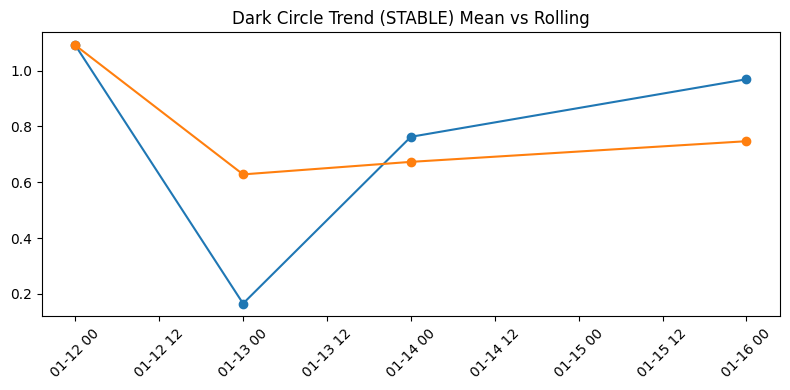

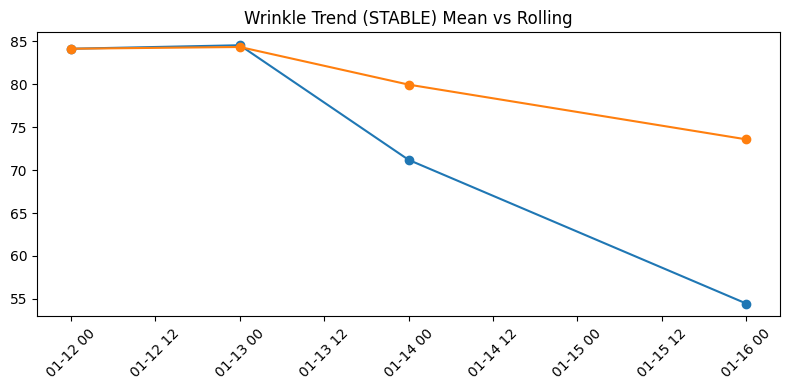

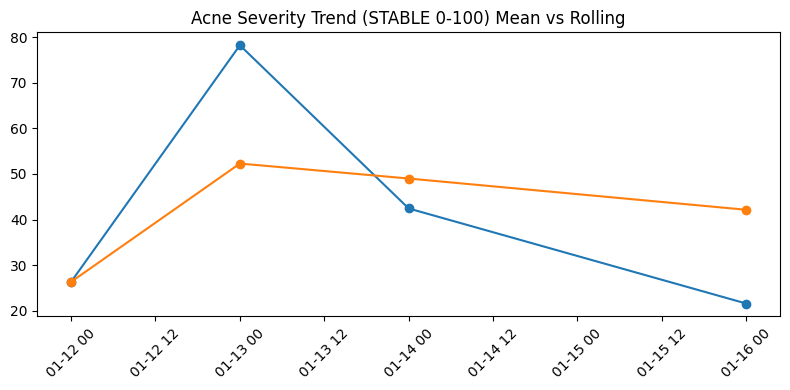

In [13]:
d = daily.copy()

plt.figure(figsize=(8,4))
plt.plot(d["date"], d["dark_circle"], marker="o")
plt.plot(d["date"], d["dark_roll"], marker="o")
plt.title("Dark Circle Trend (STABLE) Mean vs Rolling")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(d["date"], d["wrinkle"], marker="o")
plt.plot(d["date"], d["wr_roll"], marker="o")
plt.title("Wrinkle Trend (STABLE) Mean vs Rolling")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(d["date"], d["acne"], marker="o")
plt.plot(d["date"], d["ac_roll"], marker="o")
plt.title("Acne Severity Trend (STABLE 0-100) Mean vs Rolling")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Debug overlay samples (Acne stabilized)

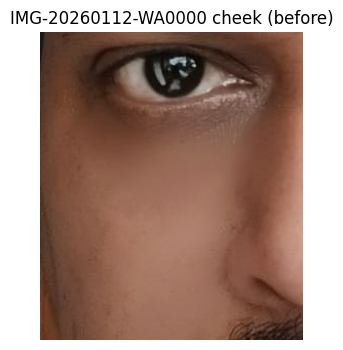

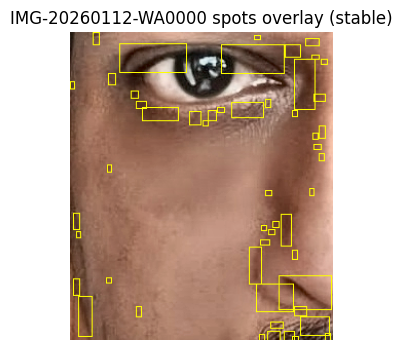

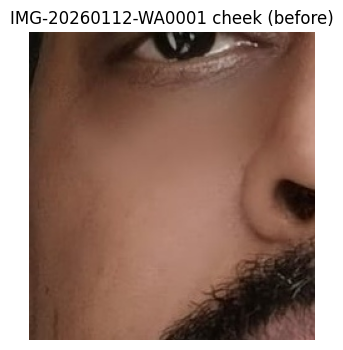

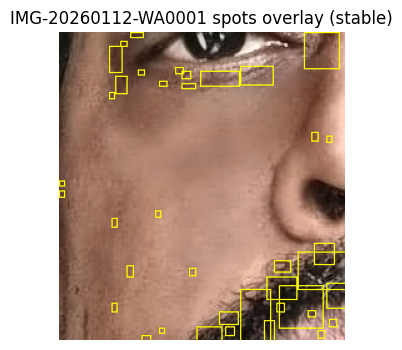

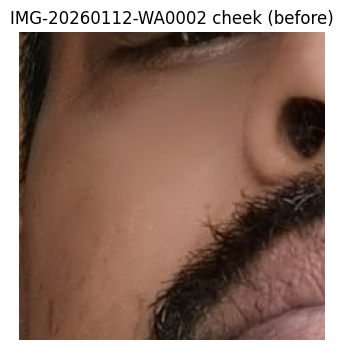

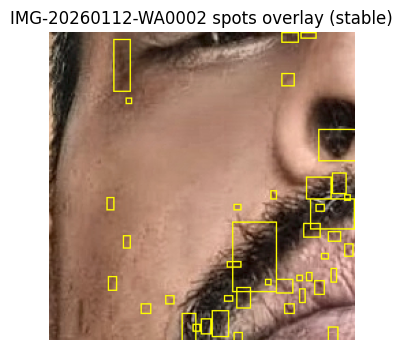

In [14]:
for image_id, before, after in debug_samples:
    show(before, f"{image_id} cheek (before)", figsize=(4,4))
    show(after,  f"{image_id} spots overlay (stable)", figsize=(4,4))

**Acne Detector V2 (Refined)**
|
...

**V2 Strategy (Realistic & Fast):**

Cheek ROI normalize (already)

Beard-zone exclude (cheek ROI’র নিচের ৩০% ignore)

Redness map (R channel – (G+B)/2) → acne bump highlight

Blob detection (threshold + contour)

Roundness filter (acne usually round-ish)

Area filter tuned

Acne Detector V2 — Drop-in Replacement

CELL — Acne V2 Function

In [15]:
def acne_count_v2(cheek_bgr):
    """
    Refined acne detector:
    - ignores bottom beard-like area
    - uses redness map to focus on pimples
    - contour filters: area + circularity
    """
    if cheek_bgr is None or cheek_bgr.size == 0:
        return None, None

    ch = normalize_roi(cheek_bgr)
    h, w = ch.shape[:2]

    # 1) Exclude bottom beard zone (bottom 30%)
    cut_y = int(0.70 * h)
    work = ch[:cut_y, :].copy()

    # 2) Redness map: R - (G+B)/2
    B, G, R = cv2.split(work.astype(np.float32))
    redness = R - 0.5*(G + B)
    redness = np.clip(redness, 0, 255).astype(np.uint8)

    # 3) Smooth to reduce noise
    redness_blur = cv2.GaussianBlur(redness, (5,5), 0)

    # 4) Normalize + threshold
    # Otsu helps auto-threshold
    _, th = cv2.threshold(redness_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 5) Morph cleanup
    kernel = np.ones((3,3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)

    # 6) Find contours
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area_img = th.shape[0] * th.shape[1]
    area_min = 0.00010 * area_img
    area_max = 0.00400 * area_img

    spots = 0
    vis = work.copy()

    for c in cnts:
        a = cv2.contourArea(c)
        if a < area_min or a > area_max:
            continue

        per = cv2.arcLength(c, True)
        if per <= 1e-9:
            continue

        # circularity = 4πA / P^2
        circ = 4*np.pi*a/(per*per)

        # keep reasonably round objects
        if circ < 0.25:
            continue

        x,y,ww,hh = cv2.boundingRect(c)
        if ww < 4 or hh < 4:
            continue

        spots += 1
        cv2.rectangle(vis, (x,y), (x+ww,y+hh), (0,255,255), 1)

    # Put excluded area back for visualization alignment
    full_vis = ch.copy()
    full_vis[:cut_y, :] = vis

    return spots, full_vis

Update our scoring loop

In [16]:
acne_l, vis_l = acne_count_v2(lch)
acne_r, vis_r = acne_count_v2(rch)

Quick Debug Cell (Before running all)

Image: IMG-20260112-WA0000 Spots: 0


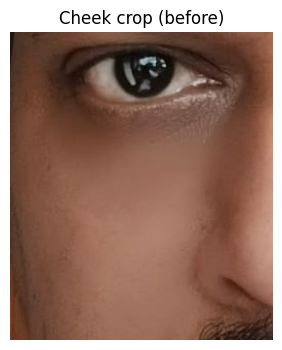

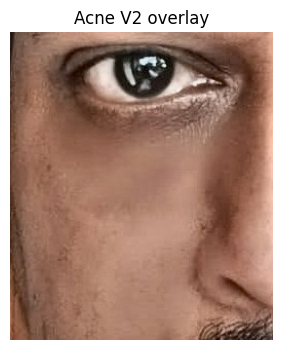

In [17]:
# pick one folder
fld = img_folders[0]
base = os.path.basename(fld)

lch = read_crop(fld, "left_cheek")
spots, vis = acne_count_v2(lch)

print("Image:", base, "Spots:", spots)
show(lch, "Cheek crop (before)", figsize=(4,4))
show(vis, "Acne V2 overlay", figsize=(4,4))

Image: IMG_20260113_154207_023 | Spots: 2


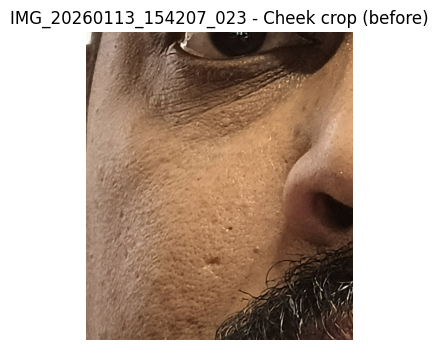

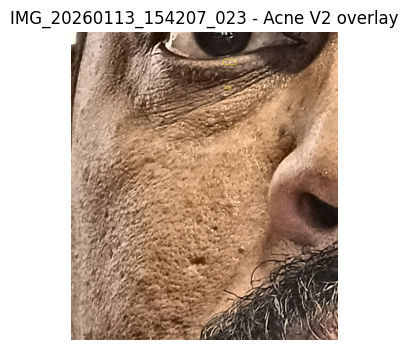

Image: IMG_20260114_144432_984 | Spots: 3


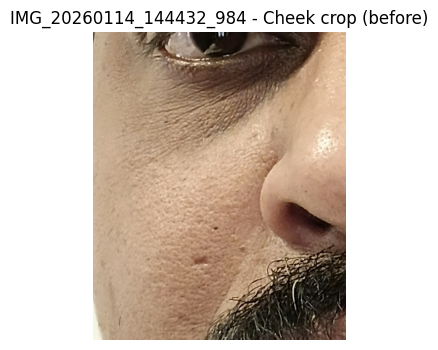

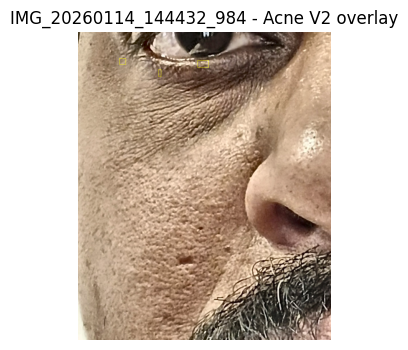

Image: IMG_20260114_144452_295 | Spots: 0


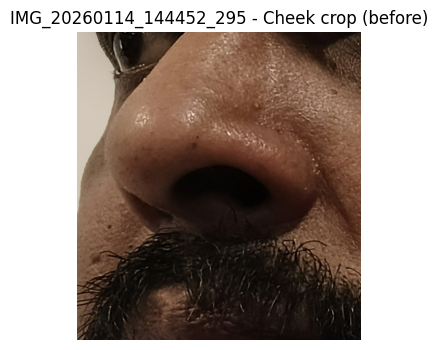

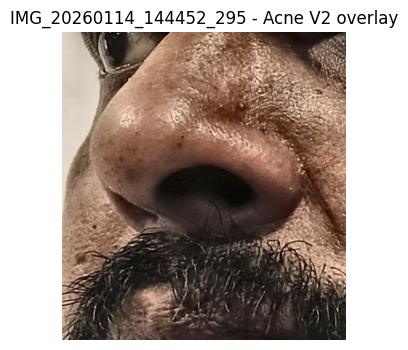

In [18]:
import random, os

for _ in range(3):
    fld = random.choice(img_folders)
    base = os.path.basename(fld)

    lch = read_crop(fld, "left_cheek")
    spots, vis = acne_count_v2(lch)

    print("Image:", base, "| Spots:", spots)
    show(lch, f"{base} - Cheek crop (before)", figsize=(4,4))
    show(vis, f"{base} - Acne V2 overlay", figsize=(4,4))

In [19]:
rows = []
debug_samples = []

for fld in tqdm(img_folders):
    image_id = os.path.basename(fld)

    forehead = read_crop(fld, "forehead")
    lue = read_crop(fld, "left_undereye")
    rue = read_crop(fld, "right_undereye")
    lch = read_crop(fld, "left_cheek")
    rch = read_crop(fld, "right_cheek")

    # Dark circle (stable)
    dc_l = dark_circle_score_stable(lue, lch)
    dc_r = dark_circle_score_stable(rue, rch)
    if dc_l is not None and dc_r is not None:
        dark_circle = float((dc_l + dc_r) / 2.0)
    else:
        dark_circle = float(dc_l) if dc_l is not None else float(dc_r) if dc_r is not None else None

    # Wrinkle (stable)
    wrinkle = wrinkle_score_stable(forehead)

    # Acne (V2)
    acne_l, vis_l = acne_count_v2(lch)
    acne_r, vis_r = acne_count_v2(rch)
    if acne_l is not None and acne_r is not None:
        acne_total = int(acne_l + acne_r)
    else:
        acne_total = int(acne_l) if acne_l is not None else int(acne_r) if acne_r is not None else None

    rows.append({
        "image_id": image_id,
        "dark_circle_score_stable": dark_circle,
        "wrinkle_score_stable": wrinkle,
        "acne_count_v2": acne_total
    })

    if len(debug_samples) < 3 and vis_l is not None:
        debug_samples.append((image_id, lch, vis_l))

stable_df_v2 = pd.DataFrame(rows)
stable_df_v2.head()

100%|██████████| 44/44 [00:11<00:00,  3.82it/s]


,image_id,dark_circle_score_stable,wrinkle_score_stable,acne_count_v2
0,IMG-20260112-WA0000,0.000000,65.530957,0
1,IMG-20260112-WA0001,0.000000,89.603506,0
2,IMG-20260112-WA0002,0.000000,100.000000,0
3,IMG-20260112-WA0003,7.395097,81.528900,1
4,IMG-20260112-WA0004,0.000000,49.070630,1


Acne count → 0–100 severity normalize + CSV save

In [20]:
def robust_0_100(series):
    s = series.astype(float).copy()
    lo = np.nanpercentile(s, 5)
    hi = np.nanpercentile(s, 95)
    if hi - lo < 1e-9:
        return pd.Series(np.zeros(len(s)), index=s.index)
    x = (s - lo) / (hi - lo)
    x = np.clip(x, 0, 1)
    return x * 100

stable_df_v2["acne_severity_v2_0_100"] = robust_0_100(stable_df_v2["acne_count_v2"])

out_csv_v2 = os.path.join(ROI_OUT_DIR, "skin_scores_stable_v2.csv")
stable_df_v2.to_csv(out_csv_v2, index=False)
print("Saved:", out_csv_v2)

stable_df_v2.describe(include="all")

Saved: /content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF/skin_scores_stable_v2.csv


,image_id,dark_circle_score_stable,wrinkle_score_stable,acne_count_v2,acne_severity_v2_0_100
count,44,44.000000,44.000000,44.000000,44.000000
unique,44,NaN,NaN,NaN,NaN
top,IMG-20260112-WA0000,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,0.810654,77.237183,3.340909,28.069658
std,NaN,1.903394,16.081375,3.490473,27.812693
min,NaN,0.000000,49.070630,0.000000,0.000000
25%,NaN,0.000000,62.757022,1.000000,8.658009
50%,NaN,0.000000,83.247443,2.000000,17.316017
75%,NaN,0.000000,90.327675,5.000000,43.290043


Trend plot (V2)

In [21]:
import re

def parse_date(image_id: str):
    m = re.search(r'(20\d{6})', str(image_id))
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")
    return pd.NaT

stable_df_v2["date"] = stable_df_v2["image_id"].apply(parse_date)
stable_df_v2 = stable_df_v2.dropna(subset=["date"]).copy()

daily_v2 = stable_df_v2.groupby("date").agg(
    photos=("image_id","count"),
    dark_circle=("dark_circle_score_stable","mean"),
    wrinkle=("wrinkle_score_stable","mean"),
    acne=("acne_severity_v2_0_100","mean"),
).reset_index().sort_values("date")

ROLL = 7
daily_v2["dark_roll"] = daily_v2["dark_circle"].rolling(ROLL, min_periods=1).mean()
daily_v2["wr_roll"]   = daily_v2["wrinkle"].rolling(ROLL, min_periods=1).mean()
daily_v2["ac_roll"]   = daily_v2["acne"].rolling(ROLL, min_periods=1).mean()

daily_v2

,date,photos,dark_circle,wrinkle,acne,dark_roll,wr_roll,ac_roll
0,2026-01-12,19,1.091235,84.148857,11.392117,1.091235,84.148857,11.392117
1,2026-01-13,9,0.165409,84.554941,43.819144,0.628322,84.351899,27.605630
2,2026-01-14,10,0.763017,71.191401,36.839827,0.673220,79.965067,30.683696
3,2026-01-16,6,0.969409,54.449883,42.640693,0.747267,73.586271,33.672945


Show plots (V2)

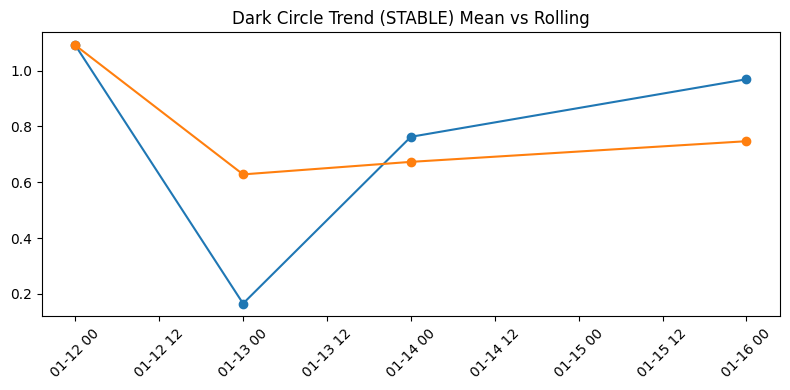

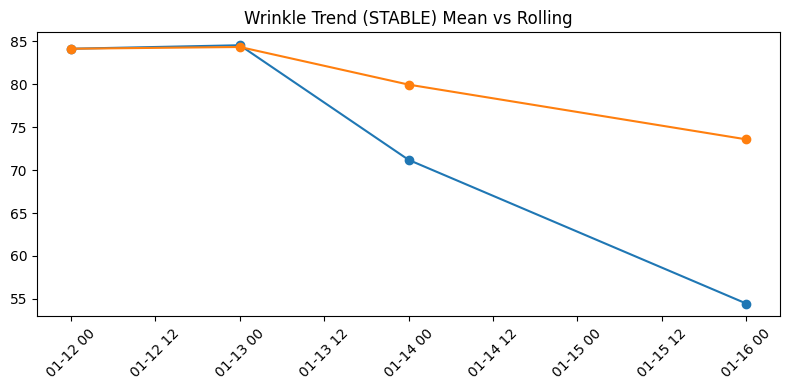

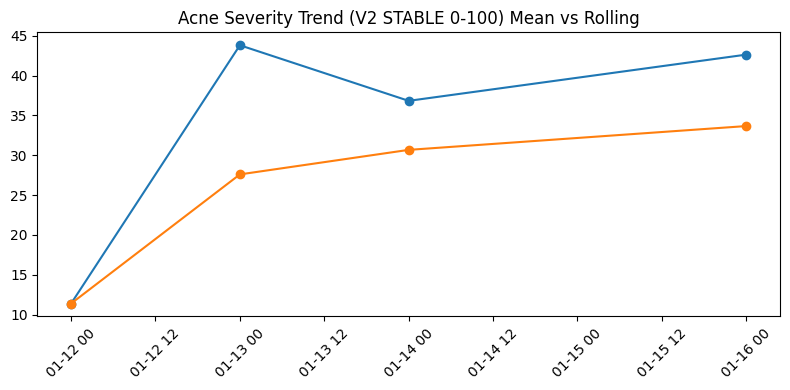

In [22]:
d = daily_v2.copy()

plt.figure(figsize=(8,4))
plt.plot(d["date"], d["dark_circle"], marker="o")
plt.plot(d["date"], d["dark_roll"], marker="o")
plt.title("Dark Circle Trend (STABLE) Mean vs Rolling")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(d["date"], d["wrinkle"], marker="o")
plt.plot(d["date"], d["wr_roll"], marker="o")
plt.title("Wrinkle Trend (STABLE) Mean vs Rolling")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(d["date"], d["acne"], marker="o")
plt.plot(d["date"], d["ac_roll"], marker="o")
plt.title("Acne Severity Trend (V2 STABLE 0-100) Mean vs Rolling")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Show debug overlays (V2) (3 sample)

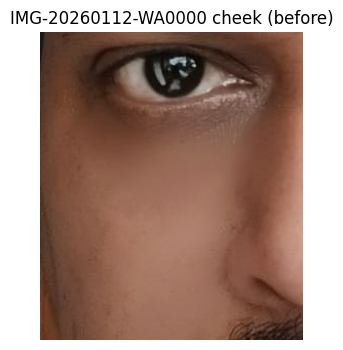

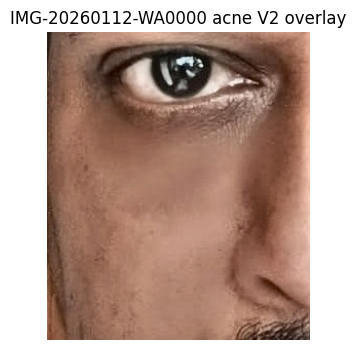

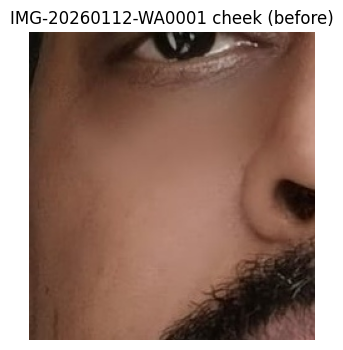

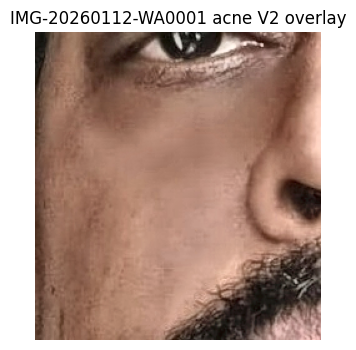

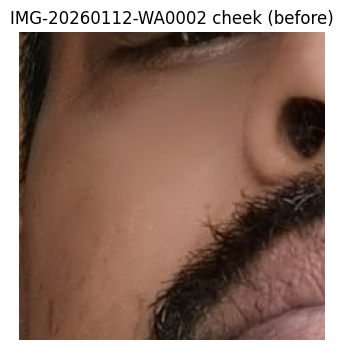

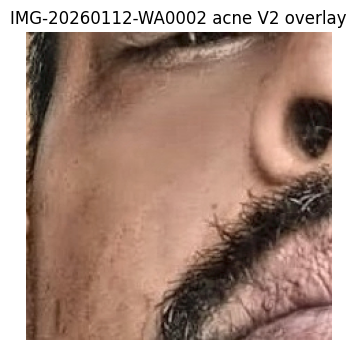

In [23]:
for image_id, before, after in debug_samples:
    show(before, f"{image_id} cheek (before)", figsize=(4,4))
    show(after,  f"{image_id} acne V2 overlay", figsize=(4,4))

Spike alerts

In [24]:
d = daily_v2.copy()

def add_spike_alert(df, col, spike_pct=30):
    prev = df[col].shift(1)
    change = (df[col] - prev) / (prev.replace(0, np.nan))
    df[col + "_spike"] = (change > (spike_pct/100.0)).fillna(False)
    return df

d = add_spike_alert(d, "dark_circle", spike_pct=30)
d = add_spike_alert(d, "wrinkle", spike_pct=20)
d = add_spike_alert(d, "acne", spike_pct=30)

d[["date","photos",
   "dark_circle","dark_circle_spike",
   "wrinkle","wrinkle_spike",
   "acne","acne_spike"
  ]]

,date,photos,dark_circle,dark_circle_spike,wrinkle,wrinkle_spike,acne,acne_spike
0,2026-01-12,19,1.091235,False,84.148857,False,11.392117,False
1,2026-01-13,9,0.165409,False,84.554941,False,43.819144,True
2,2026-01-14,10,0.763017,True,71.191401,False,36.839827,False
3,2026-01-16,6,0.969409,False,54.449883,False,42.640693,False
